# 학습 최적화와 일반화

이 노트북은 **VS Code, Colab, Jupyter에서 공통으로 사용**함. 별도 `.py` 파일은 필요하지 않음.
CPU로 실행하며 GPU는 필요하지 않음. 최초 라이브러리 설치와 Fashion-MNIST 다운로드에는 인터넷이 필요함.

## 개인 PC · VS Code 준비
1. Python 3.11 또는 3.12를 설치함. VS Code에서 Microsoft의 **Python** 및 **Jupyter** 확장을 설치함.
2. 이 `.ipynb`와 함께 제공한 `requirements.txt`를 같은 폴더에 저장하고, VS Code의 **파일 → 폴더 열기**로 그 폴더를 엶.
3. VS Code의 **터미널 → 새 터미널**을 열어 아래 명령을 운영체제에 맞게 한 줄씩 실행함. 노트북 코드 셀에 입력하는 명령이 아님.

**Windows**
```powershell
py -3.11 -m venv .venv
.venv\Scripts\python.exe -m pip install --upgrade pip
.venv\Scripts\python.exe -m pip install -r requirements.txt
```
Python 3.12를 설치했다면 첫 줄의 `-3.11`을 `-3.12`로 바꿈.

**macOS / Linux**
```bash
python3 -m venv .venv
.venv/bin/python -m pip install --upgrade pip
.venv/bin/python -m pip install -r requirements.txt
```
`python3`는 위에서 설치한 Python을 가리켜야 함. 위 명령은 가상환경을 별도로 활성화하지 않고 해당 환경에 직접 설치함.

4. 노트북을 열고 오른쪽 위 **커널 선택(Select Kernel) → Python 환경(Python Environments)**에서 이 폴더의 **`.venv`**를 선택함.
5. 첫 번째 코드 셀을 실행하여 Python·PyTorch 버전과 CPU 설정이 출력되는지 확인함. 이후 빈칸을 완성하며 위에서 아래 순서로 실행함.

**설치했는데 `ModuleNotFoundError`가 발생하면**
선택한 커널이 `.venv`인지 먼저 확인함. 필요하면 임시 코드 셀에서 아래 명령으로 현재 커널에 설치한 뒤 커널을 재시작함.
```python
%pip install -r requirements.txt
```
`requirements.txt`를 찾지 못하면 노트북과 같은 폴더에 있는지와 현재 작업 폴더를 확인함.

## Colab / Jupyter
- Colab에서는 이 파일을 업로드하고 CPU 런타임을 사용함. 위 VS Code 가상환경 설정은 필요하지 않음.
- 라이브러리 가져오기 오류가 날 때만 별도 코드 셀에서 `%pip install torch torchvision numpy matplotlib`을 실행함.
- Jupyter에서는 필요한 라이브러리가 설치된 Python 커널을 선택함.

## 실습 및 제출
- `___번호___` 17개는 의도적으로 비워 둔 과제 부분임. PPT의 참고 쪽수를 보고 완성한 뒤 해당 셀을 실행함. 빈칸을 남기면 오류가 발생할 수 있음.
- 셀은 위에서 아래 순서로 실행함. 커널을 재시작하면 앞에서 정의한 변수와 함수도 다시 실행해야 함.
- `data`와 `results`는 실행 작업 폴더에 생성됨. Colab에서는 세션 종료 전에 실행 출력이 포함된 노트북과 필요한 결과 파일을 내려받음.
- 제출은 기존 과제 안내를 따름. AI를 사용한 경우 관련 프롬프트도 함께 제출함.


In [1]:
import copy, json, random, time, platform
from pathlib import Path
import numpy as np
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from torchvision.datasets import FashionMNIST
import matplotlib.pyplot as plt
SEED, EPOCHS, BATCH, LR = 42, 160, 64, 0.05
DEVICE = torch.device('cpu')
torch.set_num_threads(2)
torch.use_deterministic_algorithms(True)
OUT = Path('results'); OUT.mkdir(exist_ok=True)
def seed_all(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
seed_all()
print('Python:', platform.python_version(), 'PyTorch:', torch.__version__)
print('CPU / seed 42 / batch 64 / SGD lr 0.05 / 160 epochs')

Python: 3.13.15 PyTorch: 2.11.0+cpu
CPU / seed 42 / batch 64 / SGD lr 0.05 / 160 epochs


## C01. Training / Validation

100%|██████████| 26.4M/26.4M [00:01<00:00, 14.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 232kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 4.30MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.9MB/s]


Train: 600 Validation: 1000
x: torch.Size([64, 1, 28, 28]) y: torch.Size([64])


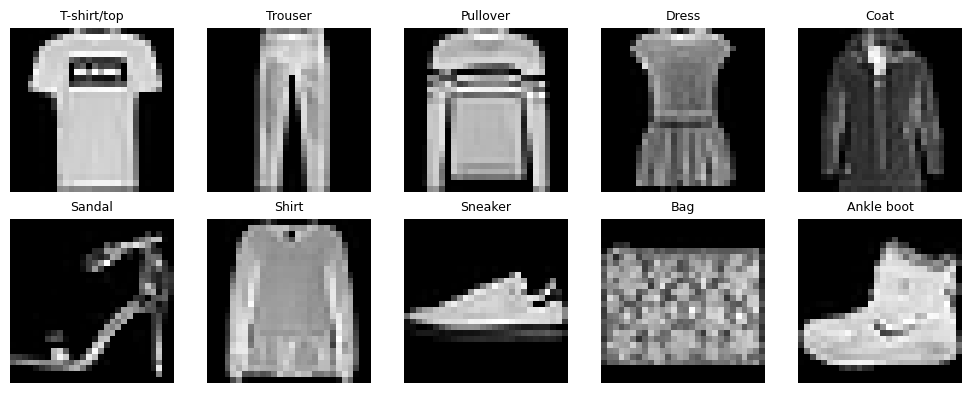

In [2]:
raw = FashionMNIST('./data', train=True, download=True)
ids = torch.randperm(len(raw), generator=torch.Generator().manual_seed(SEED))
train_ids, val_ids = ids[:600], ids[600:1600]
assert not set(train_ids.tolist()) & set(val_ids.tolist())
def subset(indices):
    return TensorDataset(raw.data[indices].unsqueeze(1).float()/255,
                         raw.targets[indices].long())
train_set, val_set = subset(train_ids), subset(val_ids)
def make_loader(ds, shuffle=False, batch_size=BATCH):
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=0,
                      generator=torch.Generator().manual_seed(SEED))
train_eval = make_loader(train_set, batch_size=256)
val_loader = make_loader(val_set, batch_size=256)
print('Train:', len(train_set), 'Validation:', len(val_set))
x, y = next(iter(make_loader(train_set)))
print('x:', x.shape, 'y:', y.shape)
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for label, ax in enumerate(axes.flat):
    index = int((raw.targets == label).nonzero()[0])
    ax.imshow(raw.data[index], cmap='gray', vmin=0, vmax=255)
    ax.set_title(raw.classes[label], fontsize=9); ax.axis('off')
plt.tight_layout(); plt.show()

## C02. Model A

In [3]:
def make_baseline():
    return nn.Sequential(
        nn.Flatten(),
        nn.Linear(784, 512),
        nn.ReLU(),
        nn.Linear(512, 10)
    )
seed_all()
model_a = make_baseline().to(DEVICE)
h = x
for layer in model_a:
    h = layer(h)
    print(type(layer).__name__, tuple(h.shape))
print('Parameters:', sum(p.numel() for p in model_a.parameters()))

Flatten (64, 784)
Linear (64, 512)
ReLU (64, 512)
Linear (64, 10)
Parameters: 407050


## C03. Forward / Loss / Backward / Update

In [4]:
# 과제: ___번호___를 PPT 11쪽의 코드로 완성함. 콜론·쉼표는 중복 입력하지 않음.
criterion = nn.CrossEntropyLoss()
def train_one_epoch(model, loader, optimizer):
    ___01___
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        ___02___
        ___03___                 # Forward: [B, 10]
        ___04___        # scalar
        ___05___                    # gradient
        ___06___                   # parameter update


## C04. Validation

In [5]:
# 과제: ___번호___를 PPT 12쪽의 코드로 완성함. 콜론·쉼표는 중복 입력하지 않음.
def evaluate(model, loader):
    was_training = model.training
    ___07___
    total_loss, correct, count = 0.0, 0, 0
    ___08___:
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            output = model(x)
            total_loss += criterion(output, y).item() * len(y)
            correct += (output.argmax(1) == y).sum().item()
            count += len(y)
    model.train(was_training)
    return total_loss/count, correct/count
print('Before training:', evaluate(model_a, val_loader))

SyntaxError: invalid syntax (931933011.py, line 6)

## C05. 반복 실행 도구

In [ ]:
def fit(model, optimizer, scheduler=None, patience=None, epochs=EPOCHS):
    seed_all()  # same dropout RNG starting state
    loader = make_loader(train_set, shuffle=True)
    history, best_state = [], None
    best_loss, best_epoch, bad = float('inf'), 0, 0
    started = time.perf_counter()
    for epoch in range(1, epochs+1):
        used_lr = optimizer.param_groups[0]['lr']
        train_one_epoch(model, loader, optimizer)
        train_loss, train_acc = evaluate(model, train_eval)
        val_loss, val_acc = evaluate(model, val_loader)
        history.append(dict(epoch=epoch, lr=used_lr, train_loss=train_loss,
                            train_acc=train_acc, val_loss=val_loss, val_acc=val_acc))
        if val_loss < best_loss:
            best_loss, best_epoch, bad = val_loss, epoch, 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            bad += 1
        if scheduler is not None:
            scheduler.step()  # next epoch uses the updated lr
        if patience is not None and bad >= patience:
            break
    final_state = copy.deepcopy(model.state_dict())
    model.load_state_dict(best_state)
    return dict(history=history, final=history[-1], best=history[best_epoch-1],
                best_state=best_state, final_state=final_state,
                stop_epoch=history[-1]['epoch'], seconds=time.perf_counter()-started)
def report(name, r):
    row = r['final']
    print(f"{name}: epoch {row['epoch']}, Train(eval) loss={row['train_loss']:.4f}, acc={row['train_acc']:.2%}")
    print(f"  Validation loss={row['val_loss']:.4f}, acc={row['val_acc']:.2%}")
    print(f"  Best validation epoch={r['best']['epoch']}, loss={r['best']['val_loss']:.4f}, time={r['seconds']:.2f}s")
def plot_history(r, title):
    h = r['history']; e = [v['epoch'] for v in h]
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
    for a, metric, ylabel in [(ax[0], 'loss', 'CrossEntropy'), (ax[1], 'acc', 'Accuracy')]:
        a.plot(e, [v['train_'+metric] for v in h], label='Train (eval mode)')
        a.plot(e, [v['val_'+metric] for v in h], label='Validation')
        a.set(xlabel='Epoch', ylabel=ylabel); a.legend(); a.grid(alpha=.2)
    fig.suptitle(title); plt.tight_layout(); plt.show()

## C06. 기준 모델 학습과 기록

In [ ]:
seed_all()
model_a = make_baseline().to(DEVICE)
initial_a = copy.deepcopy(model_a.state_dict())
opt_a = torch.optim.SGD(model_a.parameters(), lr=LR, momentum=0)
results = {'baseline': fit(model_a, opt_a)}
report('A / no dropout', results['baseline'])
plot_history(results['baseline'], 'Model A: baseline')

## C07. Scheduler의 작은 실험

In [ ]:
# 과제: ___번호___를 PPT 18쪽의 코드로 완성함.
parameter = nn.Parameter(torch.tensor(1.0))
toy_opt = torch.optim.SGD([parameter], lr=LR)
___09___
for epoch in range(1, EPOCHS+1):
    ___10___
    toy_opt.zero_grad(); (parameter*0).backward(); toy_opt.step()
    ___11___
    if epoch in [1, 50, 51, 100, 101, 150, 151]:
        print(epoch, f'used lr={used_lr:.5f}')

## C08. Weight decay의 작은 실험

In [ ]:
# 과제: ___번호___를 PPT 24쪽의 코드로 완성함. 콜론·쉼표는 중복 입력하지 않음.
w = nn.Parameter(torch.tensor([2.0, -2.0]))
___12___
w.grad = torch.zeros_like(w)
___13___
print('Weight decay only:', w.detach().tolist())  # 1.96, -1.96
print('For w=2, data gradient=0.5:', 2 - 0.1*(0.5 + 0.2*2))

## C09. Train vs Evaluation [실습 1]

In [ ]:
# 과제: ___번호___를 PPT 28쪽의 코드로 완성함. 콜론·쉼표는 중복 입력하지 않음.
seed_all()
x_small = torch.ones(12)
___14___
___15___
print('train 1:', drop(x_small).tolist())
print('train 2:', drop(x_small).tolist())
___16___
print('eval  1:', drop(x_small).tolist())
print('eval  2:', drop(x_small).tolist())
print('shape:', tuple(x_small.shape), '->', tuple(drop(x_small).shape))

## C10. Model B

In [ ]:
# 과제: ___번호___를 PPT 33쪽의 코드로 완성함. 콜론·쉼표는 중복 입력하지 않음.
def make_dropout(p):
    return nn.Sequential(
        nn.Flatten(),
        nn.Linear(784, 512),
        nn.ReLU(),
        ___17___,
        nn.Linear(512, 10)
    )
seed_all()
model_b = make_dropout(p=0.5).to(DEVICE)
for a, b in zip(initial_a.values(), model_b.state_dict().values()):
    assert torch.equal(a, b)
h = x
for layer in model_b:
    h = layer(h); print(type(layer).__name__, tuple(h.shape))
print('Parameters:', sum(p.numel() for p in model_b.parameters()))

## C11. A/B 비교 [실습 2]

In [ ]:
seed_all()
model_b = make_dropout(p=0.5).to(DEVICE)
opt_b = torch.optim.SGD(model_b.parameters(), lr=LR, momentum=0)
results['dropout'] = fit(model_b, opt_b)
report('B / dropout p=0.5', results['dropout'])
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, key in zip(axes.flat, ['train_loss', 'val_loss', 'train_acc', 'val_acc']):
    for name in ['baseline', 'dropout']:
        h = results[name]['history']
        ax.plot([r['epoch'] for r in h], [r[key] for r in h], label=name)
    ax.set(xlabel='Epoch', ylabel=key); ax.legend(); ax.grid(alpha=.2)
fig.suptitle('A/B comparison: train and validation evaluated in eval mode')
plt.tight_layout(); plt.show()

### 결과 해석 [실습 2]
1. 마지막 epoch의 4개의 지표를 기록함. 어느 지표가 개선됐는지 수치로 설명함.
2. 최저 검증 손실의 epoch는 두 모델에서 같은가?
3. Training Accuracy가 반드시 내려가야 Dropout이 정상 작동하는가?
4. 이 결과만으로 Dropout이 항상 좋다고 결론 내릴 수 있는가?
훈련 과정의 무작위 제거와 평가 모드의 측정을 구분해 설명함.

**해석:**

- 예상:
- 관찰 수치와 epoch 구간:
- 예상과 달랐던 이유에 대한 가설:

## C12. Scheduler와 Weight decay
두 조건 모두 **기준 모델에서 각각 출발**함. 앞서 학습한 Dropout 모델에 누적 적용하지 않음.
Weight decay 조건은 weight만 λ=0.001 적용, bias 제외임. 비교 손실에 벌점을 더하지 않음.

In [ ]:
seed_all()
model_s = make_baseline().to(DEVICE)
opt_s = torch.optim.SGD(model_s.parameters(), lr=LR, momentum=0)
scheduler = torch.optim.lr_scheduler.StepLR(opt_s, step_size=50, gamma=0.3)
results['scheduler'] = fit(model_s, opt_s, scheduler=scheduler)
seed_all()
model_w = make_baseline().to(DEVICE)
weights = [v for name, v in model_w.named_parameters() if name.endswith('weight')]
biases = [v for name, v in model_w.named_parameters() if name.endswith('bias')]
opt_w = torch.optim.SGD([{'params': weights, 'weight_decay': 0.001},
                         {'params': biases, 'weight_decay': 0.0}], lr=LR, momentum=0)
results['weight_decay'] = fit(model_w, opt_w)
for name in ['baseline', 'scheduler', 'weight_decay', 'dropout']:
    report(name, results[name])
for name in ['baseline', 'scheduler', 'weight_decay']:
    h = results[name]['history']
    plt.plot([r['epoch'] for r in h], [r['val_loss'] for r in h], label=name)
plt.xlabel('Epoch'); plt.ylabel('Validation CrossEntropy'); plt.legend(); plt.grid(alpha=.2); plt.show()

## C13. Early stopping

In [ ]:
seed_all()
model_e = make_baseline().to(DEVICE)
opt_e = torch.optim.SGD(model_e.parameters(), lr=LR, momentum=0)
results['early_stop'] = fit(model_e, opt_e, patience=8)
r = results['early_stop']
print('Stop epoch:', r['stop_epoch'], 'Restore epoch:', r['best']['epoch'])
print('Restored validation:', evaluate(model_e, val_loader))
print('Continued baseline best:', results['baseline']['best']['epoch'],
      results['baseline']['best']['val_loss'])
assert abs(evaluate(model_e, val_loader)[0] - r['best']['val_loss']) < 1e-6

## C14. 선택과 기록

In [ ]:
candidates = ['baseline', 'scheduler', 'weight_decay', 'dropout']
selected = min(candidates, key=lambda name: results[name]['best']['val_loss'])
print('Selected:', selected, 'epoch:', results[selected]['best']['epoch'])
torch.save(results[selected]['best_state'], OUT/'selected_weights.pt')
config = dict(seed=SEED, train_size=600, val_size=1000, epochs=EPOCHS,
              batch_size=BATCH, lr=LR, optimizer='SGD momentum=0',
              model='784-512-10', dropout_p=0.5, weight_decay=0.001,
              scheduler_step_size=50, scheduler_gamma=0.3, patience=8,
              device=str(DEVICE), torch_version=str(torch.__version__),
              selection='minimum validation CrossEntropy',
              test_used=False, selected=selected)
def save_results():
    clean = {k:{a:b for a,b in v.items() if a not in ['best_state','final_state']}
             for k,v in results.items()}
    (OUT/'results.json').write_text(json.dumps(dict(config=config, results=clean), indent=2))
save_results()
print('Saved:', OUT/'results.json')

## C15. 과제 · p=0.2 추가 실행

In [ ]:
P_TRY = 0.2
seed_all()
model_try = make_dropout(p=P_TRY).to(DEVICE)
opt_try = torch.optim.SGD(model_try.parameters(), lr=LR, momentum=0)
trial_key = f'p{round(P_TRY*10):02d}'
results[trial_key] = fit(model_try, opt_try)
report(f'p={P_TRY}', results[trial_key])
plot_history(results[trial_key], f'experiment: p={P_TRY}')
save_results()

## 과제 · 비교와 제출
p=0.0, 0.2, 0.5, 0.7을 같은 조건으로 비교함. C15를 복사해 P_TRY만 0.7로 바꿈. 0.0·0.5는 앞선 baseline·dropout 결과를 재사용함. 네 지표·학습 곡선·최저 검증 손실과 epoch를 기록하고 선택 이유를 5~7문장 작성함. 완성 코드와 실행 출력이 포함된 이 노트북을 제출함.

## 제출

- AI를 사용한 경우, 입력한 프롬프트를 함께 제출함. 여러 차례 질문했다면 관련 프롬프트를 순서대로 첨부함.

- 실행 출력이 포함된 ipynb를 제출함